# PV + battery energy storage

A standalone PNM-data demonstration: load data, declare the PV/BES assets and economics, dispatch, calculate LCOE, plot, and run resilience cases.

In [1]:
from pathlib import Path
import sys
import pandas as pd

root = Path.cwd()
while not (root / 'enliten').is_dir():
    if root.parent == root: raise RuntimeError('Run from inside the ENLITEN repository.')
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
from enliten import ChargingPath, Generation, LCOECalculator, Site, Storage, System
data_dir = root / 'examples' / 'data'

def profile(filename):
    frame = pd.read_csv(data_dir / filename)
    return pd.Series(frame['PNM'].to_numpy(float), index=pd.to_datetime(frame.iloc[:, 0], utc=True))

demand_full = profile('PNM_demand.csv')
pv_full = profile('PNM_pv_ac_1MW_av.csv')
assert demand_full.index.equals(pv_full.index)

# Use the complete aligned 2023 profiles for annual operational and LCOE results.
load = (demand_full * 0.05).rename('load_MW')
pv_multiplier, bes_capacity_MWh, bes_power_MW = 3_000.0, 750.0, 150.0
pv_capex = pv_full.max() * pv_multiplier * 1_000 * 1_430
pv_opex = pv_full.max() * pv_multiplier * 1_000 * 24
bes_capex = bes_capacity_MWh * 1_000 * 300

site = Site('microgrid')
pv = Generation('pv', site, pv_full * pv_multiplier, 'electric', capex=pv_capex, opex=pv_opex)
bes = Storage('bes', site, bes_capacity_MWh, bes_power_MW, 'electric', 'electric', 0.90,
              maximum_stored_energy_rate_MW=bes_power_MW, capex=bes_capex, opex=0.025 * bes_capex)
path = ChargingPath('pv', 'bes', 'electric', 'electric', 0.90, bes_power_MW / 0.90)
system = System(load, [bes, pv], [path])
system.timeseries.head(24)

,load_MW,grid_to_load_MWh_electric,unmet_load_MWh_electric,export_energy_MWh_electric,pv_available_MW_electric,pv_to_load_MWh_electric,pv_to_grid_MWh_electric,pv_curtailed_MWh_electric,pv_to_bes_MWh_electric,pv_to_bes_stored_MWh_electric,bes_MWh_electric,bes_to_load_MWh_electric,bes_loss_MWh_electric,microgrid_POI_MW_electric
date_time,,,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,84.48,0.000000,0.0,0.0,0.158849,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 01:00:00+00:00,91.86,91.860000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 02:00:00+00:00,92.71,92.710000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 03:00:00+00:00,91.48,91.480000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 04:00:00+00:00,90.35,90.350000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 05:00:00+00:00,88.59,88.590000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 06:00:00+00:00,86.17,86.170000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 07:00:00+00:00,83.79,83.790000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2023-01-01 08:00:00+00:00,81.62,81.620000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000


In [2]:
system.operation_metrics()

{'operating_hours': 8759,
 'load_MWh_electric': 714158.81,
 'generation_to_load_MWh_electric': 305903.8760946745,
 'storage_to_load_MWh_electric': 118657.7619851093,
 'system_to_load_MWh_electric': 424561.6380797839,
 'grid_to_load_MWh_electric': 289597.1719202162,
 'unmet_load_MWh_electric': 0.0,
 'export_energy_MWh_electric': 0.0,
 'percent_load_met': 99.99999999999999,
 'percent_load_by_system': 59.449191431214565,
 'system_capex_USD': 440580965.5543319,
 'system_annual_OM_USD': 9243142.079233542,
 'pv_curtailed_MWh_electric': 0.0,
 'load_annual_MWh_electric': [714240.3442858774],
 'system_to_load_annual_MWh_electric': [424610.1095534772],
 'grid_to_load_annual_MWh_electric': [289630.2347324003],
 'export_energy_annual_MWh_electric': [0.0],
 'annual_electricity_sales_USD': [0.0],
 'annual_electricity_purchases_USD': [0.0],
 'system_annual_VOM_USD': 0.0,
 'system_augment_USD': [0.0],
 'system_augment': [0.0]}

In [3]:
lcoe_metrics = LCOECalculator.from_system(system, analysis_period=30).calculate_lcoe_metrics()
lcoe_metrics

{'PVD': 0.7673732703594979,
 'FCR_AT': 0.036148074230068654,
 'FCR_BT': 0.05294061134598742,
 'CRF': 0.07650022967642069,
 'NPV_cash_flow': -459809205.93344665,
 'IRR': nan,
 'payback_period': None,
 'LCOE_real_USD_kWh_BT': 0.085218552761941,
 'LCOE_real_USD_kWh_AT': 0.060010719624116714}

mkdir -p failed for path C:\Users\jenni\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jenni\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jenni\AppData\Local\Temp\matplotlib-jxn_wt21 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


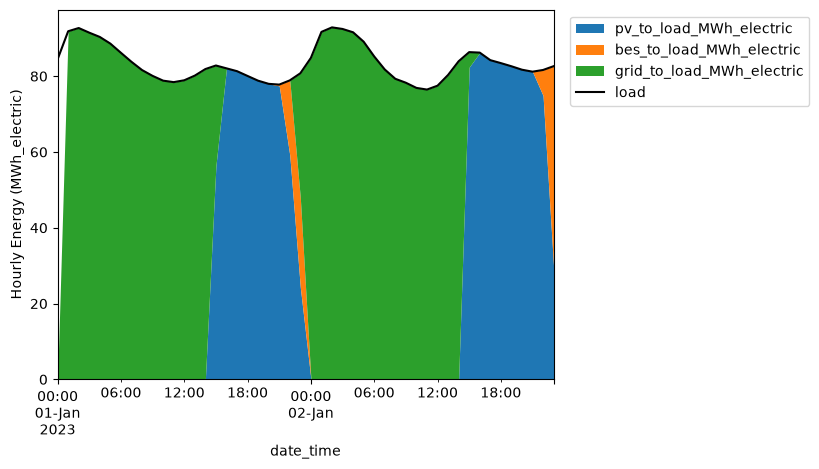

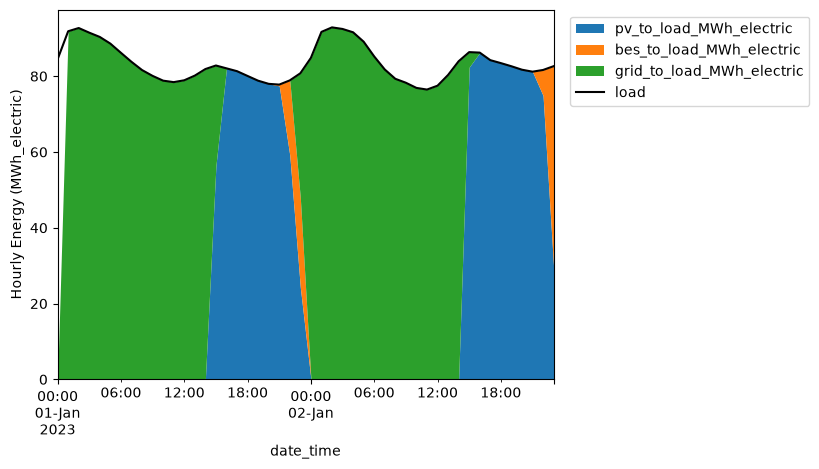

In [4]:
fig, ax = system.timeseries_plot_source(start_date=0, days=2)
fig

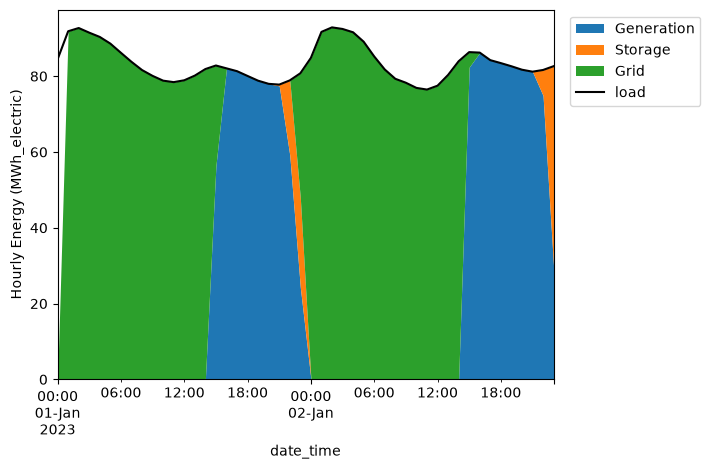

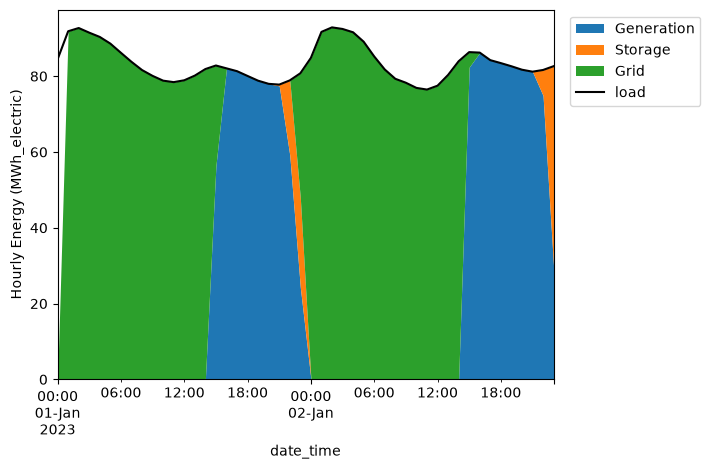

In [5]:
fig, ax = system.timeseries_plot_group(start_date=0, days=2)
fig

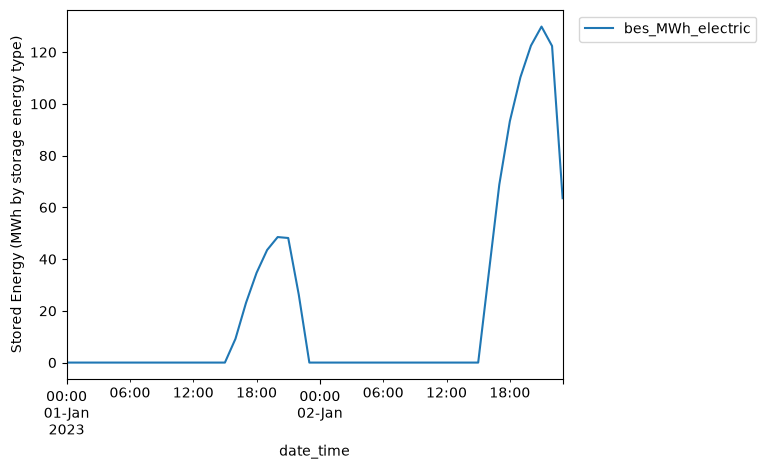

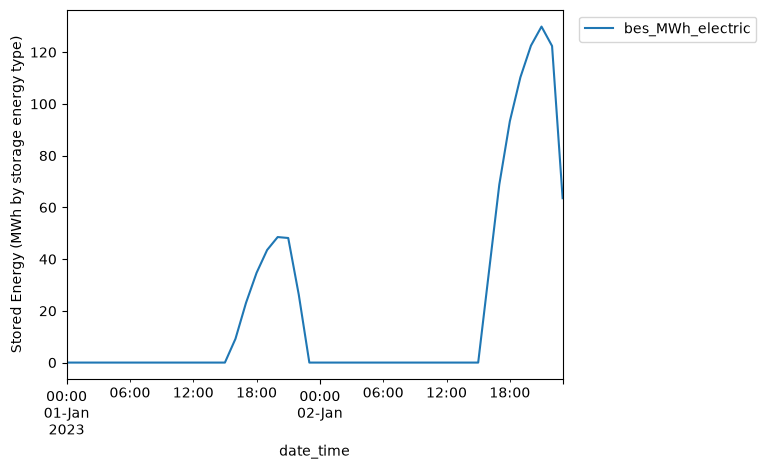

In [6]:
fig, ax = system.plot_storage_capacity(start_date=0, days=2)
fig

In [7]:
cases = system.resilience_cases(critical_load_MW=20.0, target_hours=24, n_starts=20, seed=7)
display(cases)
system.resilience_summary

,start_hour,actual_duration_hours,full_duration_hours,actual_reaches_target,full_reaches_target,to_end_actual,to_end_full,pct_target_energy_actual,pct_target_energy_full,target_energy_actual_MWh_electric,target_energy_full_MWh_electric,target_energy_actual,target_energy_full
0,5305,7,24,False,True,False,True,0.868608,1.0,63.068231,0.0,63.068231,0.0
1,2471,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
2,6468,0,24,False,True,False,True,0.967830,1.0,15.441571,0.0,15.441571,0.0
3,791,7,24,False,True,False,True,0.687731,1.0,149.889071,0.0,149.889071,0.0
4,1186,0,24,False,True,False,True,0.875000,1.0,60.000000,0.0,60.000000,0.0
5,1542,0,24,False,True,False,True,0.708333,1.0,140.000000,0.0,140.000000,0.0
6,5991,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
7,950,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0
8,8313,0,24,False,True,False,True,0.793014,1.0,99.353280,0.0,99.353280,0.0
9,3517,24,24,True,True,True,True,1.000000,1.0,0.000000,0.0,0.000000,0.0


{'n_starts': 20,
 'pct_meets_actual': 45.0,
 'pct_meets_full': 100.0,
 'actual_reaches_end_pct': 45.0,
 'full_reaches_end_pct': 100.0,
 'tenth_pctile_actual_hrs': 0.0,
 'tenth_pctile_target_energy_actual_MWh_electric': 0.0,
 'tenth_pctile_target_energy_actual': 0.0,
 'tenth_pctile_pct_target_energy_actual': 75.25623386670851,
 'fiftieth_pctile_actual_hrs': 9.0,
 'fiftieth_pctile_target_energy_actual_MWh_electric': 16.767630966818,
 'fiftieth_pctile_target_energy_actual': 16.767630966818,
 'fiftieth_pctile_pct_target_energy_actual': 96.50674354857959,
 'ninetieth_pctile_actual_hrs': 24.0,
 'ninetieth_pctile_target_energy_actual_MWh_electric': 118.7700774397992,
 'ninetieth_pctile_target_energy_actual': 118.7700774397992,
 'ninetieth_pctile_pct_target_energy_actual': 100.0,
 'pct_meets_target_energy_actual': 45.0,
 'tenth_pctile_full_hrs': 24.0,
 'tenth_pctile_target_energy_full_MWh_electric': 0.0,
 'tenth_pctile_target_energy_full': 0.0,
 'tenth_pctile_pct_target_energy_full': 100.0,
 '